In [1]:
%%time
import spatialdata as sd
import spatialdata_plot  # noqa: F401

sdata = sd.read_zarr(r"data/melanoma.zarr")
sdata

/Users/lyuan13/anaconda3/envs/spatial/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/lyuan13/anaconda3/envs/spatial/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
version mismatch: detected: RasterFormatV02, requested: FormatV04
/Users/lyuan13/anaconda3/envs/spatial/lib/python3.11/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, f

CPU times: user 3.64 s, sys: 2.21 s, total: 5.84 s
Wall time: 4.98 s


SpatialData object, with associated Zarr store: /Users/lyuan13/Desktop/HOT-NERD/tutorials/melanoma/data/melanoma.zarr
├── Images
│     └── 'morphology_focus': DataTree[cyx] (4, 20294, 42748), (4, 10147, 21374), (4, 5073, 10687), (4, 2536, 5343), (4, 1268, 2671)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (20294, 42748), (10147, 21374), (5073, 10687), (2536, 5343), (1268, 2671)
│     └── 'nucleus_labels': DataTree[yx] (20294, 42748), (10147, 21374), (5073, 10687), (2536, 5343), (1268, 2671)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (112551, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (112551, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (109795, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (112551, 5006)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), cell_labels (Labels), nucleus_labels (La

In [2]:
transcripts = sdata.points["transcripts"].compute()
transcripts.shape

(74011892, 13)

In [3]:
# Filter by qv > 30
filtered_df = transcripts[transcripts["qv"] > 30]

# Filter by feature_name
genes = sdata.tables["table"].var.index
filtered_df = filtered_df[filtered_df["feature_name"].isin(genes)]
filtered_df.shape

(55582003, 13)

In [4]:
filtered_df.head()

,x,y,z,feature_name,cell_id,codeword_category,is_gene,overlaps_nucleus,nucleus_distance,qv,codeword_index,fov_name,transcript_id
0,150.953125,2204.703125,30.328125,A2ML1,aanjmada-1,predesigned_gene,True,0,18.203125,40.00,12771,Y5,281629596018242
1,159.296875,2245.125000,34.281250,A2ML1,aaocjllh-1,predesigned_gene,True,0,3.671875,30.75,12771,Y5,281629596018337
2,203.781250,2190.953125,31.062500,A2ML1,aanidcai-1,predesigned_gene,True,1,0.000000,40.00,12771,Y5,281629596019123
3,205.046875,2189.468750,34.484375,A2ML1,aanidcai-1,predesigned_gene,True,0,0.343750,33.25,12771,Y5,281629596019149
4,99.734375,2221.406250,32.187500,A2ML1,dbinnkdn-1,predesigned_gene,True,0,0.921875,40.00,12771,Y5,281629596219319


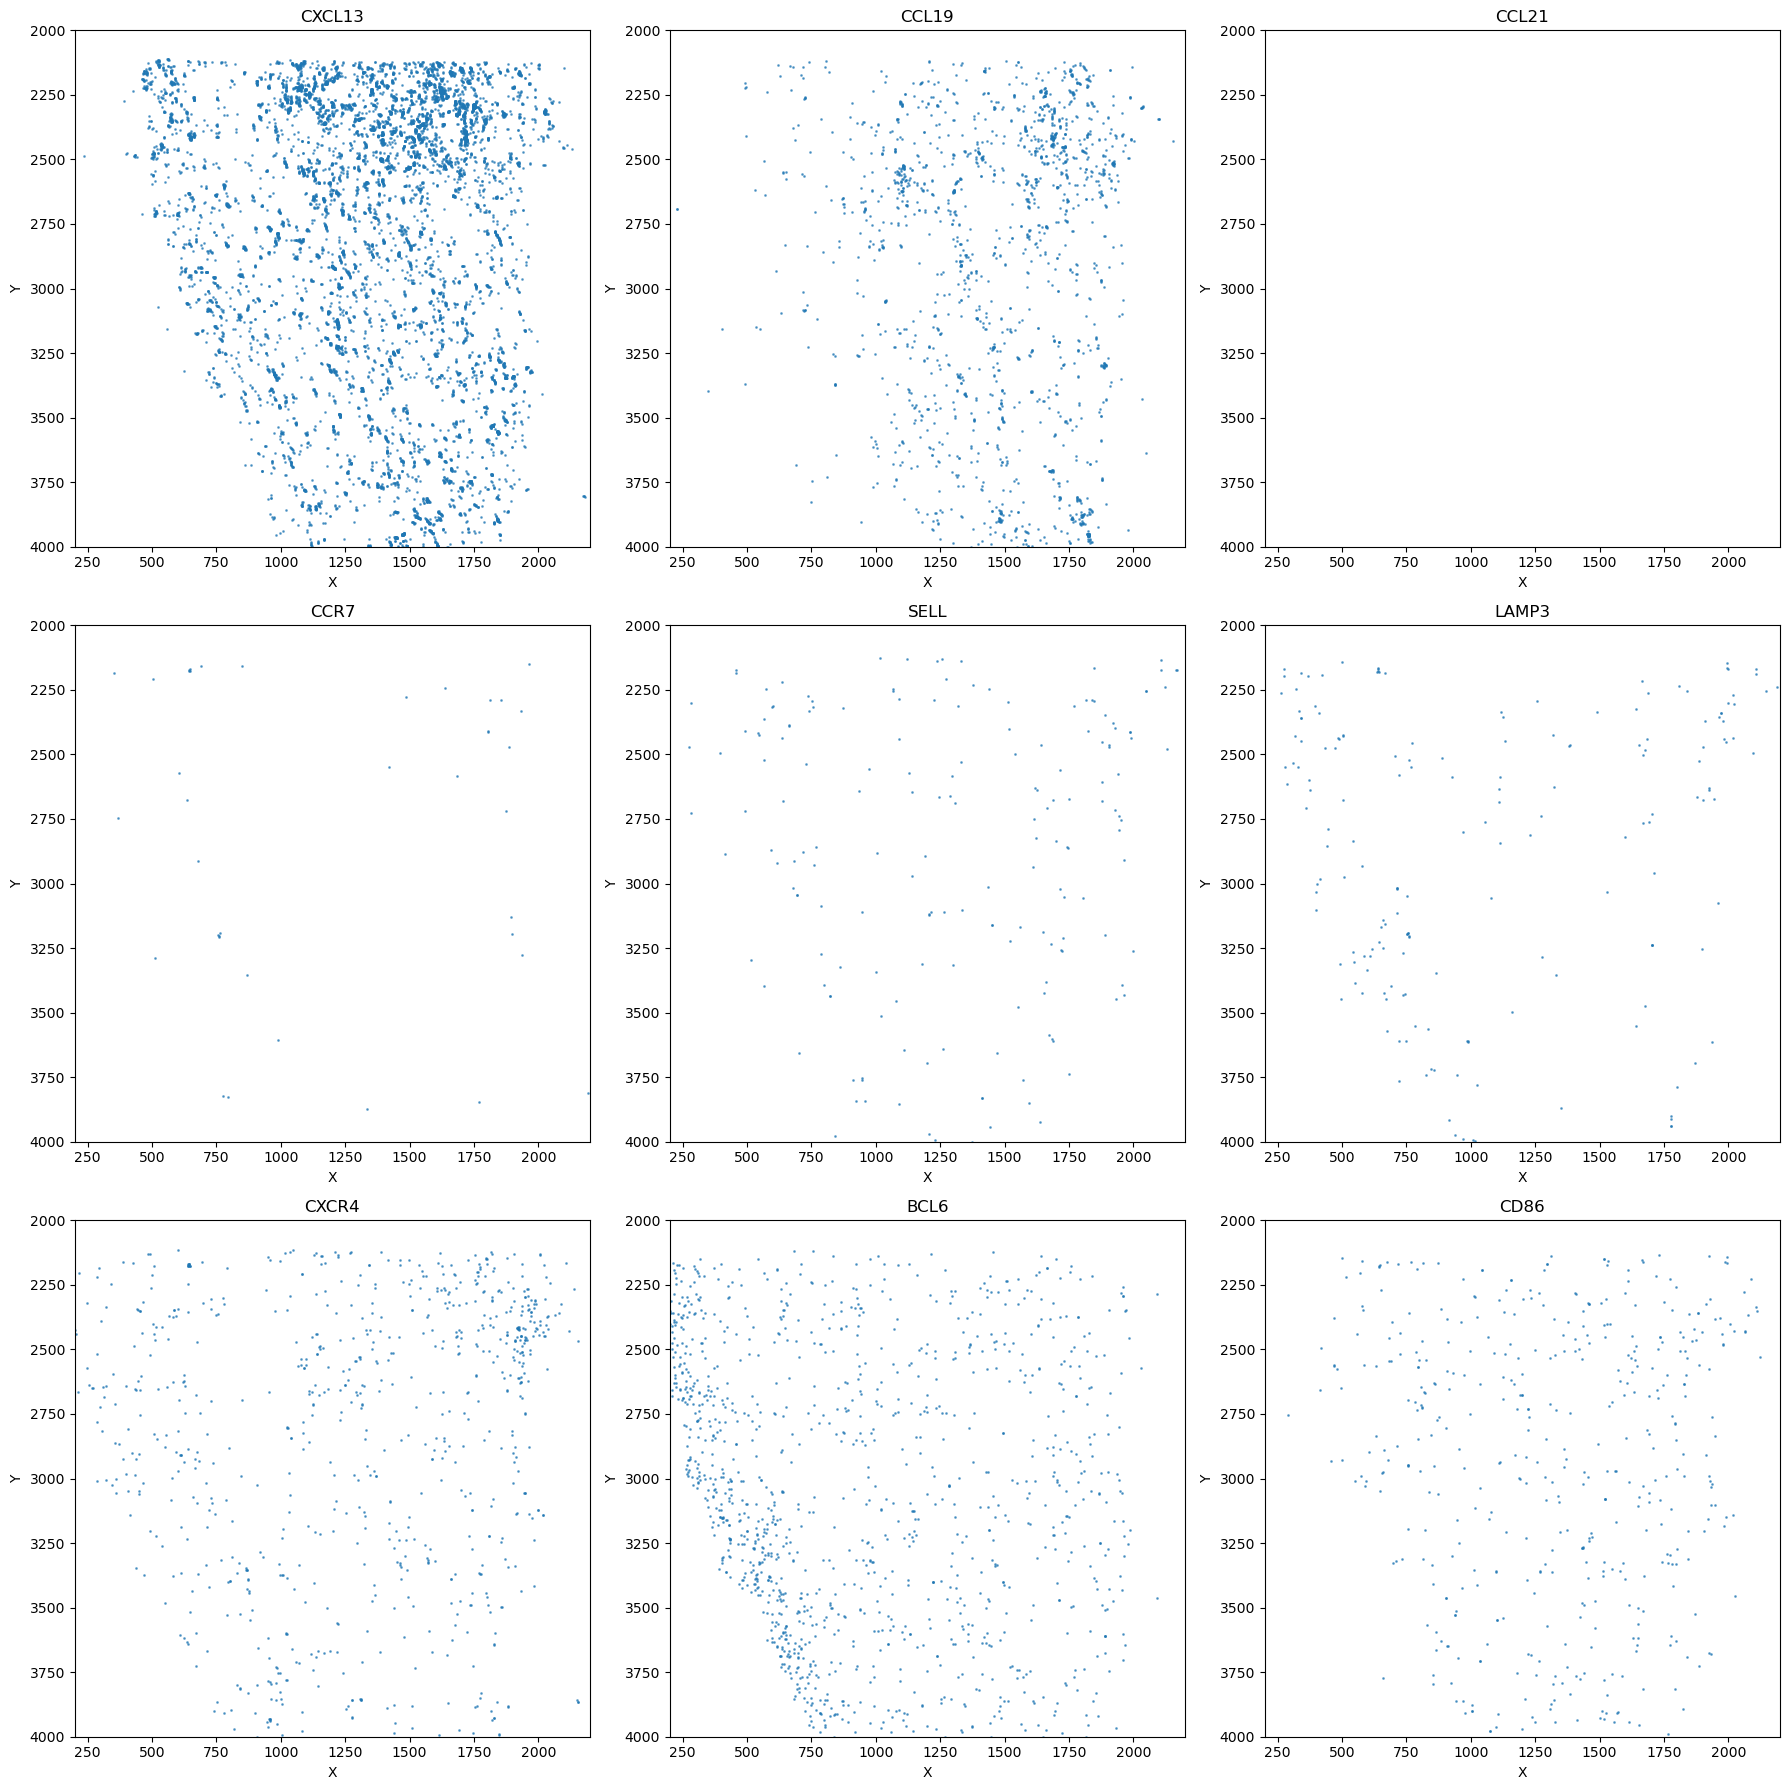

In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes = axes.flatten()

genes_of_interest = ["CXCL13","CCL19","CCL21","CCR7","SELL","LAMP3","CXCR4","BCL6","CD86"]

for ax, gene in zip(axes, genes_of_interest):
    gene_points = filtered_df[filtered_df['feature_name'] == gene]
    ax.scatter(gene_points['x'], gene_points['y'], s=1, alpha=0.6)
    ax.set_title(gene)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_xlim(200, 2200)
    ax.set_ylim(2000, 4000)
    ax.invert_yaxis()  # match image coordinate system

plt.tight_layout()
plt.show()

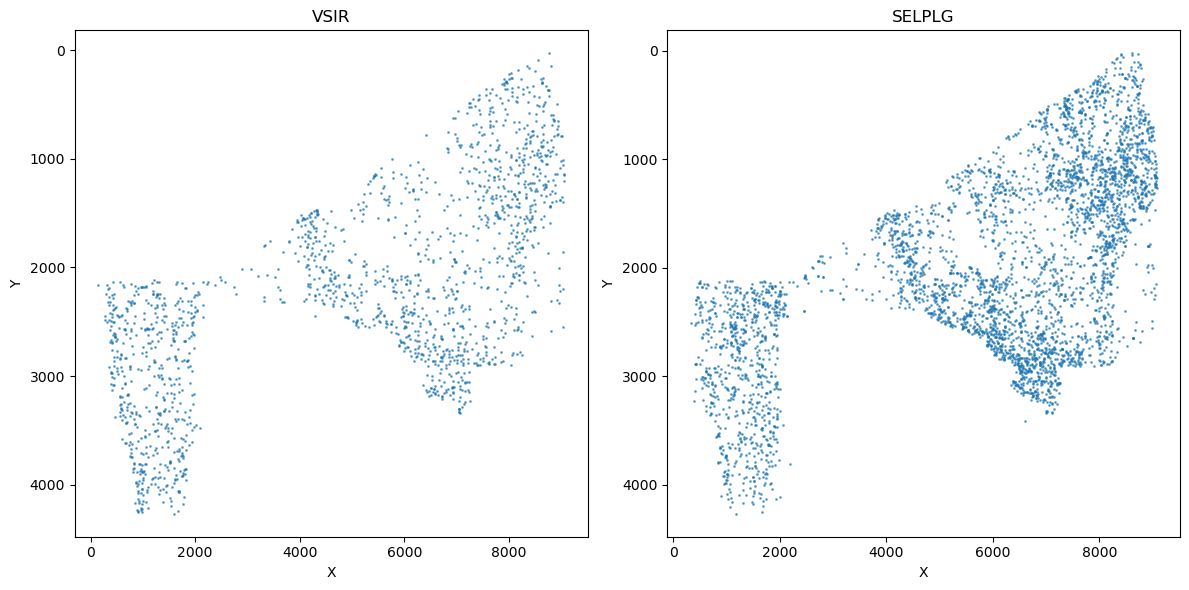

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes = axes.flatten()

genes_of_interest = ["VSIR", "SELPLG"]

for ax, gene in zip(axes, genes_of_interest):
    gene_points = filtered_df[filtered_df['feature_name'] == gene]
    ax.scatter(gene_points['x'], gene_points['y'], s=1, alpha=0.6)
    ax.set_title(gene)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.invert_yaxis()  # match image coordinate system

plt.tight_layout()
plt.show()

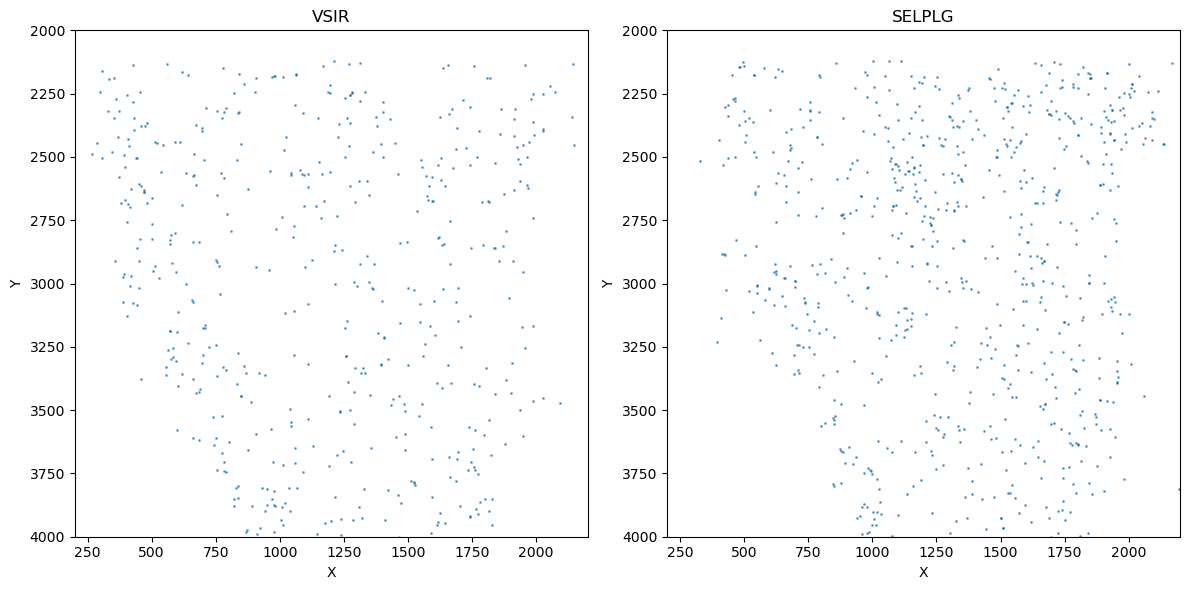

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes = axes.flatten()

genes_of_interest = ["VSIR", "SELPLG"]

for ax, gene in zip(axes, genes_of_interest):
    gene_points = filtered_df[filtered_df['feature_name'] == gene]
    ax.scatter(gene_points['x'], gene_points['y'], s=1, alpha=0.6)
    ax.set_title(gene)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_xlim(200, 2200)
    ax.set_ylim(2000, 4000)
    ax.invert_yaxis()  # match image coordinate system
    #ax.set_ylim(0, 2000)
    #ax.set_xlim(7250, 9250)

    
plt.tight_layout()
plt.show()

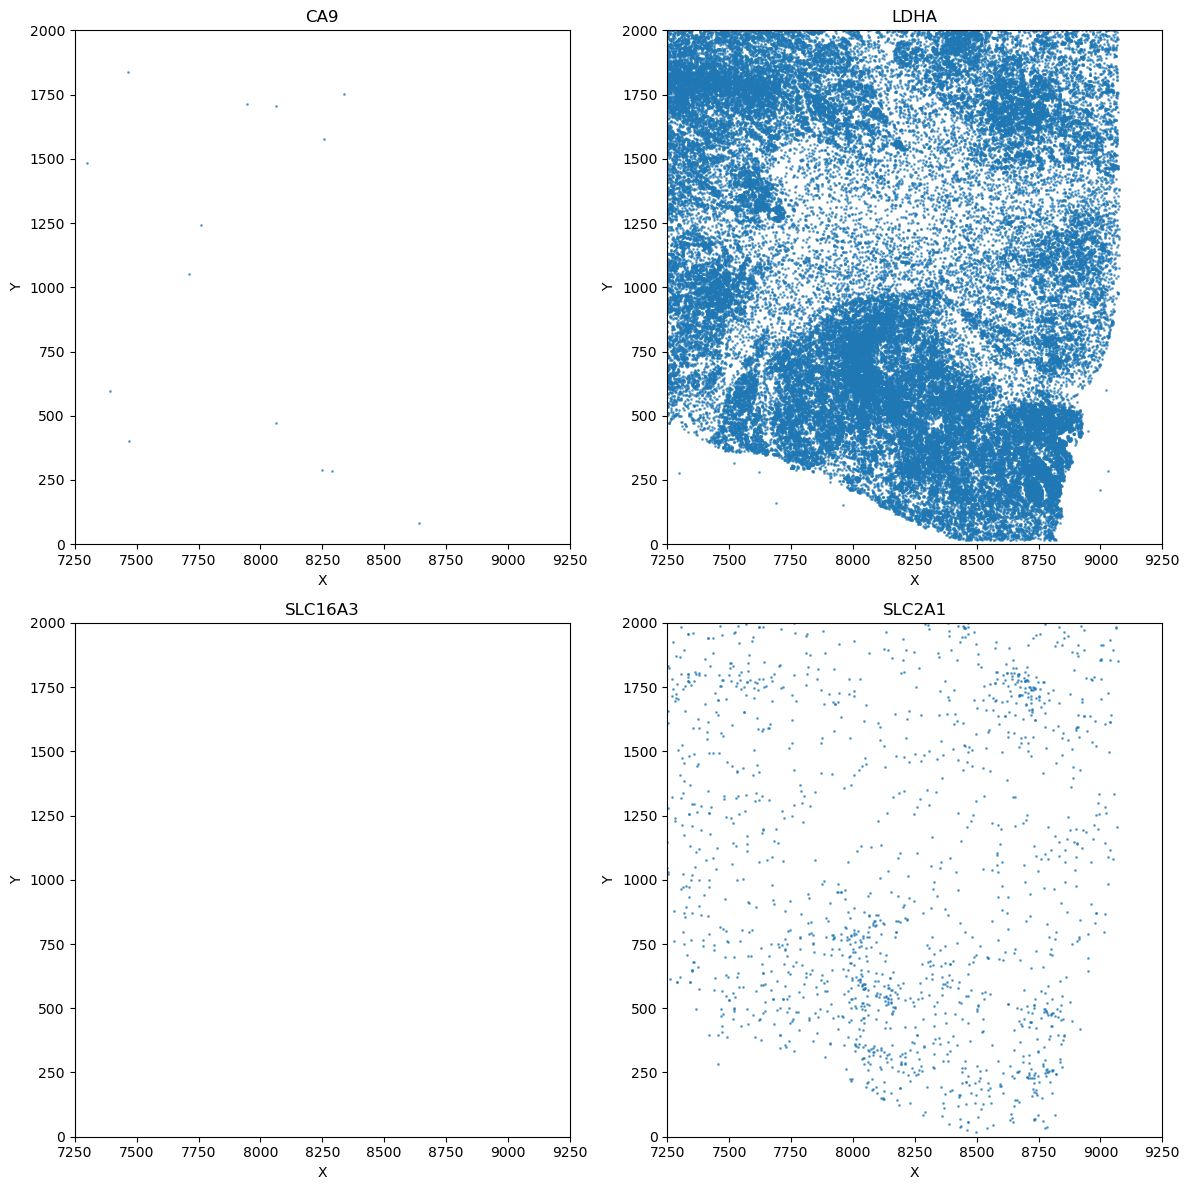

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

genes_of_interest = ['CA9','LDHA','SLC16A3','SLC2A1']

for ax, gene in zip(axes, genes_of_interest):
    gene_points = filtered_df[filtered_df['feature_name'] == gene]
    ax.scatter(gene_points['x'], gene_points['y'], s=1, alpha=0.6)
    ax.set_title(gene)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_xlim(200, 2200)
    ax.set_ylim(2000, 4000)
    ax.invert_yaxis()  # match image coordinate system
    ax.set_ylim(0, 2000)
    ax.set_xlim(7250, 9250)

plt.tight_layout()
plt.show()

Largest cell radius: 17.990735281189757
99th percentile of radius: 9.324119804340997


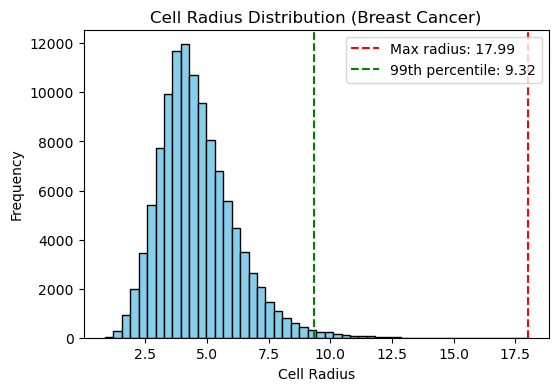

In [28]:
import numpy as np

# Extract radii
cells_gdf = sdata.shapes['cell_circles']
radii = cells_gdf['radius']

# Compute stats
max_radius = radii.max()
percentile_99 = np.percentile(radii, 99)

print(f"Largest cell radius: {max_radius}")
print(f"99th percentile of radius: {percentile_99}")

# Plot histogram
plt.figure(figsize=(6,4))
plt.hist(radii, bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Cell Radius')
plt.ylabel('Frequency')
plt.title('Cell Radius Distribution (Breast Cancer)')

# Annotate max and 99th percentile
plt.axvline(max_radius, color='red', linestyle='--', label=f'Max radius: {max_radius:.2f}')
plt.axvline(percentile_99, color='green', linestyle='--', label=f'99th percentile: {percentile_99:.2f}')

# Add legend
plt.legend()
plt.show()

In [8]:
import numpy as np
import pandas as pd
import geopandas as gpd
#
def get_confident_nuclei_transcripts(
    sdata,
    *,
    qv_min: float = 30,
    low_pct: float = 20,
    high_pct: float = 80,
    save_qv_filtered: bool = False,
    parquet_path: str = "qv_filtered_transcripts.parquet",
):
    """
    From a SpatialData object, extract high-quality nucleus transcripts and
    return a confident nucleus DataFrame (nuc_df_confident).

    Parameters
    ----------
    sdata : SpatialData
        The loaded SpatialData object.
    qv_min : float
        Minimum qv to keep.
    low_pct : float
        Lower percentile threshold for nucleus transcript count.
    high_pct : float
        Upper percentile threshold for nucleus transcript count.
    save_qv_filtered : bool
        If True, save the QV-filtered transcripts to a Parquet file.
    parquet_path : str
        Path to save QV-filtered transcripts if requested.

    Returns
    -------
    nuc_df_confident : DataFrame
        Transcripts belonging to confident nuclei.
    fitlered_df : DataFrame
        Transcripts passing the qv threshold.
    """

    # Load transcripts
    transcripts = sdata.points["transcripts"].compute()

    # Apply QV filter
    df = transcripts[transcripts["qv"] >= qv_min].copy()

    # Filter to valid gene list
    # Ensures we only keep transcripts whose gene exists in AnnData table
    valid_genes = set(sdata.tables["table"].var.index)
    df = df[df["feature_name"].isin(valid_genes)].copy()

    # Optionally save the qv-filtered transcripts
    if save_qv_filtered:
        df.to_parquet(parquet_path, index=False)
        qv_out = parquet_path
        print("Saved parquet:", qv_out)
    else:
        qv_out = None

    # Extract nucleus-overlapping transcripts with a valid cell_id
    nuc_df = df[
        (df["cell_id"] != "UNASSIGNED") &
        (df["overlaps_nucleus"] == 1)
    ].copy()

    # Compute transcript-count thresholds per nucleus
    nuc_counts = nuc_df.groupby("cell_id").size()

    low_thres = np.percentile(nuc_counts, low_pct)
    high_thres = np.percentile(nuc_counts, high_pct)
    print("Transcript count thresholds:", low_thres, high_thres)

    # Identify confident nuclei
    good_ids = nuc_counts[(nuc_counts >= low_thres) & (nuc_counts <= high_thres)].index
    
    print("Number of confident nuclei:", len(good_ids))
    nuc_df_confident = nuc_df[nuc_df["cell_id"].isin(good_ids)].copy()

    return nuc_df_confident, df

In [9]:
nuc_df_confident, filtered_df = get_confident_nuclei_transcripts(
    sdata,
    qv_min=30,
    low_pct=20,
    high_pct=80,
    save_qv_filtered=False,
)

Transcript count thresholds: 35.0 272.0
Number of confident nuclei: 66149


In [10]:
def compute_npmi(
    df_subset,
    group_key="cell_id",
    min_occurrences_per_context=2
):
    """
    Compute PMI/NPMI using presence/absence of genes at the cell or nucleus level,
    with robustness control by requiring each gene to occur at least N times
    within a context (cell or nucleus) before being considered "present".

    Returns
    -------
    long_df : DataFrame
        Columns:
            gene_i, gene_j, P_i, P_j, P_ij,
            P_i_given_j, P_j_given_i, PMI, NPMI
    """

    # 0. Subset to necessary columns
    df = df_subset[[group_key, "feature_name"]].copy()

    # ----------------------------------------------------------------------
    # Filter by minimum occurrences per context
    # ----------------------------------------------------------------------
    # Count gene occurrences within each cell/nucleus
    counts = (
        df.groupby([group_key, "feature_name"])
        .size()
        .rename("gene_count")
        .reset_index()
    )

    # Keep only those gene occurrences with enough counts
    df_filtered = counts[counts["gene_count"] >= min_occurrences_per_context].copy()

    if df_filtered.empty:
        raise ValueError(
            f"No genes pass min_occurrences_per_context={min_occurrences_per_context}."
        )

    # For presence/absence, set value = 1 for all retained (context, gene) pairs
    df_filtered["value"] = 1

    # ----------------------------------------------------------------------
    # Pivot to contexts × genes matrix (presence/absence)
    # ----------------------------------------------------------------------
    M = df_filtered.pivot_table(
        index=group_key,
        columns="feature_name",
        values="value",
        aggfunc="max",
        fill_value=0
    )

    contexts = M.index.to_numpy()
    genes = M.columns.to_numpy()
    C = M.shape[0]

    # ----------------------------------------------------------------------
    # Probabilities P(i), P(i,j)
    # ----------------------------------------------------------------------
    counts_i = M.sum(axis=0).to_numpy()
    P_i = counts_i / C

    co_matrix = (M.T @ M).to_numpy()
    P_ij = co_matrix / C

    # ----------------------------------------------------------------------
    # Conditional probabilities
    # ----------------------------------------------------------------------
    P_i_col = P_i[:, None]
    P_j_row = P_i[None, :]

    with np.errstate(divide="ignore", invalid="ignore"):
        P_i_given_j = np.where(P_j_row > 0, P_ij / P_j_row, np.nan)
        P_j_given_i = np.where(P_i_col > 0, P_ij / P_i_col, np.nan)

    # ----------------------------------------------------------------------
    # PMI & NPMI
    # ----------------------------------------------------------------------
    PMI = np.full_like(P_ij, np.nan)
    NPMI = np.full_like(P_ij, np.nan)

    denom = P_i_col * P_j_row
    valid = (P_ij > 0) & (denom > 0)

    with np.errstate(divide="ignore", invalid="ignore"):
        PMI[valid] = np.log(P_ij[valid] / denom[valid])
        NPMI[valid] = PMI[valid] / (-np.log(P_ij[valid]))

    # ----------------------------------------------------------------------
    # Convert to long format
    # ----------------------------------------------------------------------
    G = len(genes)
    long_df = pd.DataFrame({
        "gene_i": np.repeat(genes, G),
        "gene_j": np.tile(genes, G),
        "P_i": np.repeat(P_i, G),
        "P_j": np.tile(P_i, G),
        "P_ij": P_ij.ravel(),
        "P_i_given_j": P_i_given_j.ravel(),
        "P_j_given_i": P_j_given_i.ravel(),
        "PMI": PMI.ravel(),
        "NPMI": NPMI.ravel(),
    })

    return long_df

In [11]:
nucleus_npmi_long = compute_npmi(nuc_df_confident, group_key="cell_id", min_occurrences_per_context=2)

/var/folders/_2/50fjjk3d1696gqy3jz2ypb9j88m1t6/T/ipykernel_49689/1035429692.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([group_key, "feature_name"])
/var/folders/_2/50fjjk3d1696gqy3jz2ypb9j88m1t6/T/ipykernel_49689/1035429692.py:47: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  M = df_filtered.pivot_table(


In [12]:
print("PMI: min =", np.nanmin(nucleus_npmi_long.PMI), "max =", np.nanmax(nucleus_npmi_long.PMI))
print("NPMI: min =", np.nanmin(nucleus_npmi_long.NPMI), "max =", np.nanmax(nucleus_npmi_long.NPMI))

PMI: min = -5.071545123752296 max = 11.090232811195438
NPMI: min = -0.4683029825069227 max = 1.0000000000000002


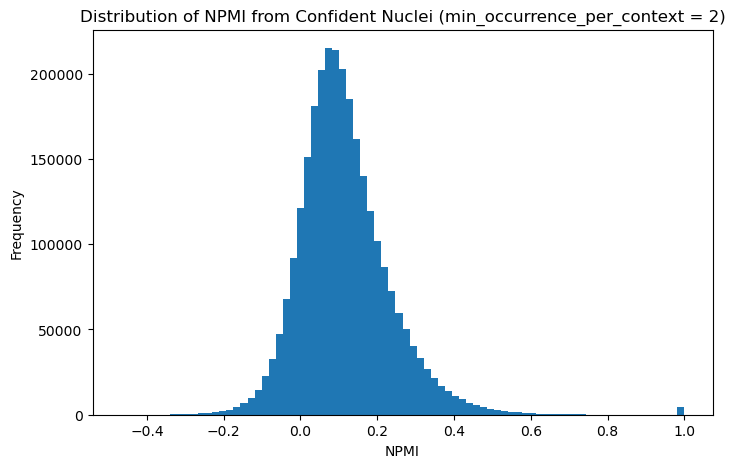

Top 10 highest NPMI gene pairs:
            gene_i   gene_j       P_i       P_j      P_ij  P_i_given_j  \
3755049     CRHR2     PRPH  0.000015  0.000015  0.000015     1.000000   
4168425    CYP1A1  CYP24A1  0.000015  0.000015  0.000015     1.000000   
4181541   CYP24A1   CYP1A1  0.000015  0.000015  0.000015     1.000000   
8057687     IL17B    NTSR2  0.000015  0.000015  0.000015     1.000000   
11463475    NTSR2    IL17B  0.000015  0.000015  0.000015     1.000000   
12579625    PLIN4    PLIN5  0.000015  0.000015  0.000015     1.000000   
12583997    PLIN5    PLIN4  0.000015  0.000015  0.000015     1.000000   
13185453     PRPH    CRHR2  0.000015  0.000015  0.000015     1.000000   
3671019      CPA4     KPRP  0.000855  0.001053  0.000794     0.753623   
9061695      KPRP     CPA4  0.001053  0.000855  0.000794     0.928571   

          P_j_given_i        PMI      NPMI  
3755049      1.000000  11.090233  1.000000  
4168425      1.000000  11.090233  1.000000  
4181541      1.000000  11.09

In [13]:
# exclude self-pairs
nucleus_npmi_pairs = nucleus_npmi_long[
    nucleus_npmi_long["gene_i"] != nucleus_npmi_long["gene_j"]
].copy()

plt.figure(figsize=(8,5))
#plt.hist(nucleus_npmi_pairs["NPMI"].dropna(), bins=80)
plt.hist(nucleus_npmi_long["NPMI"].dropna(), bins=80)
plt.xlabel("NPMI")
plt.ylabel("Frequency")
plt.title("Distribution of NPMI from Confident Nuclei (min_occurrence_per_context = 2)")
plt.show()

# Top 10 positive
top10 = nucleus_npmi_pairs.nlargest(10, "NPMI")
print("Top 10 highest NPMI gene pairs:\n", top10)

# Bottom 10
bottom10 = nucleus_npmi_pairs.nsmallest(10, "NPMI")
print("Bottom 10 lowest NPMI gene pairs:\n", bottom10)

In [24]:
# define ROI
x_min, x_max = 200, 2200
y_min, y_max = 2000, 4000

# get cell IDs with at least one transcript in the ROI, excluding UNASSIGNED
region_cells = filtered_df[
    (filtered_df['x'] >= x_min) & (filtered_df['x'] <= x_max) &
    (filtered_df['y'] >= y_min) & (filtered_df['y'] <= y_max) &
    (filtered_df['cell_id'] != "UNASSIGNED")
]['cell_id'].unique()

# subset original DataFrame
subset_df = filtered_df[
    (filtered_df['cell_id'].isin(region_cells)) |  # all transcripts from selected cells
    (
        (filtered_df['cell_id'] == "UNASSIGNED") &  # OR
        (filtered_df['x'] >= x_min) & (filtered_df['x'] <= x_max) &
        (filtered_df['y'] >= y_min) & (filtered_df['y'] <= y_max)
    )
]

print(f"Number of transcripts in subset: {len(subset_df)}")
print(f"Number of unique cells (excluding UNASSIGNED): {subset_df[subset_df['cell_id'] != 'UNASSIGNED']['cell_id'].nunique()}")

Number of transcripts in subset: 6856972
Number of unique cells (excluding UNASSIGNED): 16931


In [25]:
nucleus_npmi_long.to_csv("data/melanoma_npmi.csv", index=False)
subset_df.to_parquet("data/melanoma_df.parquet", index=False)